In [49]:
# Exploratory Data Analysis (EDA) libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [51]:
print(f"Shape of the dataset : {df.shape}")
print('='*80)
print(df.info())
print('='*80)
print("Statistical summery of numerical columns : ")
print('-'*80)
print(df.describe())

Shape of the dataset : (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
Statistical summery of numerical columns : 
------------

In [52]:
# Renaming some columns
df = df.rename(columns={
    'pclass': 'ticket_class',
    'sibsp': 'siblings_spous',
    'parch': 'parent_children'
})

In [53]:
# percentage of missing values in every column
missing_percentage = df.isnull().mean() * 100
print("Percenyage of missing values")
print('-'*50)
print(missing_percentage.round(2))

Percenyage of missing values
--------------------------------------------------
survived            0.00
ticket_class        0.00
sex                 0.00
age                19.87
siblings_spous      0.00
parent_children     0.00
fare                0.00
embarked            0.22
class               0.00
who                 0.00
adult_male          0.00
deck               77.22
embark_town         0.22
alive               0.00
alone               0.00
dtype: float64


In [54]:
df.to_csv("titanic.csv", index=False)

### Missing-value handling 

The missing-value strategy follows a data-quality rule that is appropriate for each column based on how much data is missing:

- For columns with less than 5% missing values, we drop the affected rows because the missingness is low and removing a small number of records keeps the dataset clean without distorting the distribution.
- For columns with 5% to 30% missing values, we impute the missing entries using the column mean. This is a reasonable choice for continuous numeric data such as age because it preserves the sample size and avoids losing rows while keeping the imputed values centered around the dataset’s typical value.
- For columns with more than 30% missing values, we remove the entire column. When a feature is missing for a large majority of records, keeping it would add noise and provide little analytical value.

This approach balances data retention and reliability: it removes only minor data loss cases, imputes where a central estimate is defensible, and drops columns that are too sparse to be informative.

In this notebook, the `age` column is imputed with the mean because it has about 19.86% missing values, which falls inside the 5%–30% band. The `embark_town` column is cleaned by dropping rows because it has only about 0.22% missing values, which is below 5%. The `deck` column is removed entirely because it has about 77.22% missing data, which exceeds 30%.

In [55]:
print("Missing values before applying new rules:")
missing_before = df.isnull().sum()
missing_percent_before = (missing_before / len(df)) * 100

for col in missing_percent_before[missing_percent_before > 0].index:
    print(f"Column '{col}' : {missing_percent_before[col]:.2f}% missing")

Missing values before applying new rules:
Column 'age' : 19.87% missing
Column 'embarked' : 0.22% missing
Column 'deck' : 77.22% missing
Column 'embark_town' : 0.22% missing


In [56]:
# Apply missing value handling based on the specified thresholds

# Column 'age': 19.86% missing (between 5% and 30%) -> Impute with mean
age_missing_percent = missing_percent_before['age']
if age_missing_percent > 5 and age_missing_percent <= 30:
    df['age'] = df['age'].fillna(df['age'].mean())
    print(f"\nStrategy for 'age' ({age_missing_percent:.2f}% missing): Imputed with mean.")

# Column 'embark_town': 0.22% missing (under 5%) -> Drop rows
embark_town_missing_percent = missing_percent_before['embark_town']
if embark_town_missing_percent > 0 and embark_town_missing_percent <= 5:
    initial_rows = len(df)
    df.dropna(subset=['embark_town'], inplace=True)
    rows_dropped = initial_rows - len(df)
    print(f"\nStrategy for 'embark_town' ({embark_town_missing_percent:.2f}% missing): Dropped {rows_dropped} rows.")
# Column 'deck' : 77.22% missing (graten than 30%) -> drop entire column
# (Note: 'deck' was dropped due to high missing rate, this aligns with >30% rule)
deck_missing_percentage = missing_percent_before['deck']
if deck_missing_percentage > 30:
    df = df.drop('deck',axis = 1)
    print(f"\nStrategy for 'deck' ({deck_missing_percentage:.2f}% missing): Dropped the whole column.")
print('-'*80)
print("Missing values after applying new rules to the fresh dataset:")
print('-'*80)
print(df.isnull().sum())


Strategy for 'age' (19.87% missing): Imputed with mean.

Strategy for 'embark_town' (0.22% missing): Dropped 2 rows.

Strategy for 'deck' (77.22% missing): Dropped the whole column.
--------------------------------------------------------------------------------
Missing values after applying new rules to the fresh dataset:
--------------------------------------------------------------------------------
survived           0
ticket_class       0
sex                0
age                0
siblings_spous     0
parent_children    0
fare               0
embarked           0
class              0
who                0
adult_male         0
embark_town        0
alive              0
alone              0
dtype: int64


### EDA-only z-score check for age and fare

This is a quick exploratory sanity check only. The full modeling pipeline will apply its own scaling separately using train-only statistics; this step is only to confirm that the transformed variables behave as expected in the cleaned data.

We standardize `age` and `fare` using the z-score formula $z = \frac{x - \mu}{\sigma}$, then confirm that the transformed columns have approximately mean 0 and standard deviation 1.


--- Univariate Analysis for 'age' and 'fare' ---


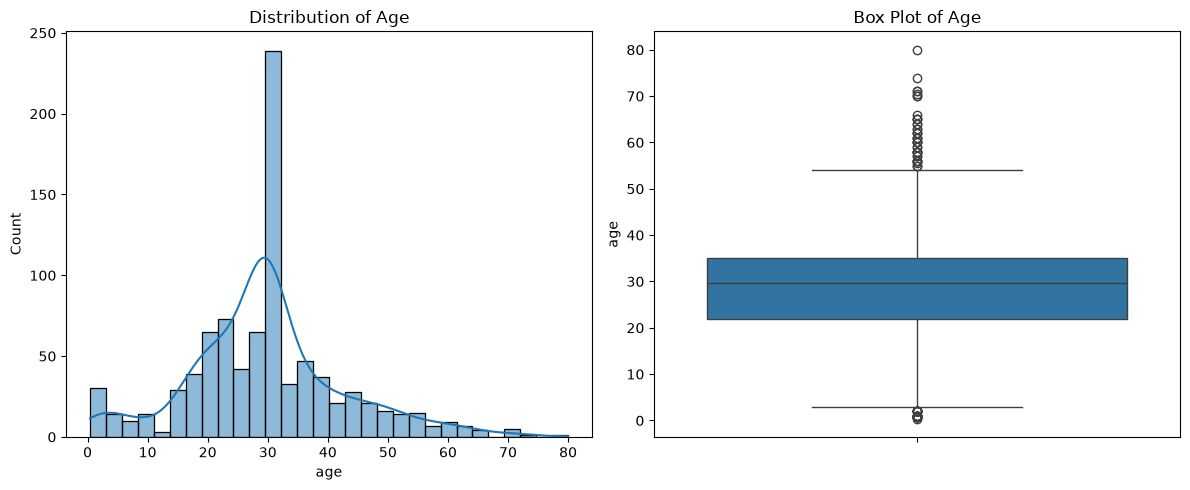

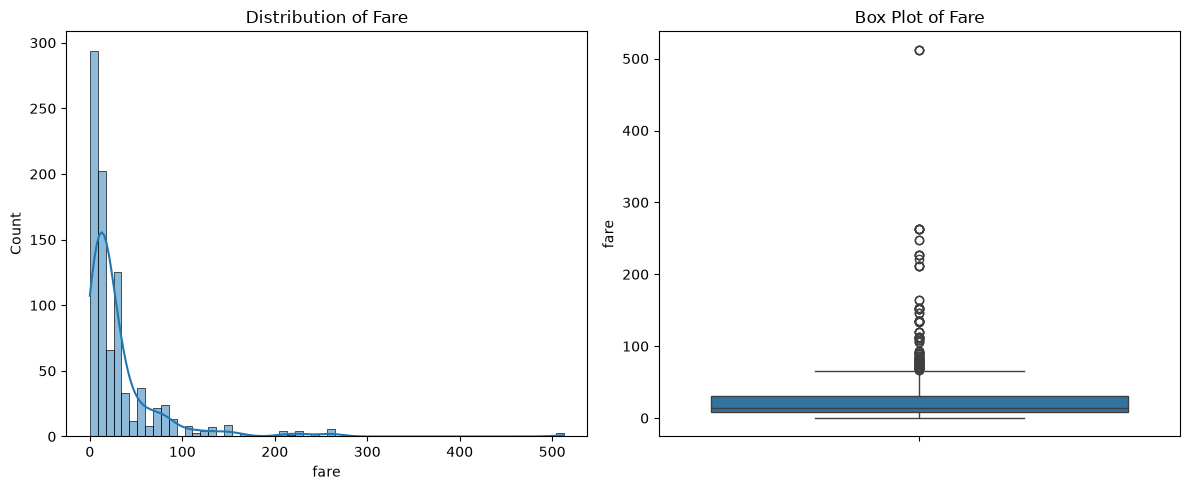


'Age' outliers (IQR rule): 65 outliers detected.
'Fare' outliers (IQR rule): 114 outliers detected.


In [57]:
# Univariate analysis

print("\n--- Univariate Analysis for 'age' and 'fare' ---")

# Plot histogram and box plot for age
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Box Plot of Age')
plt.tight_layout()
plt.show()

# Plot histogram and box plot for fare
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['fare'], kde=True)
plt.title('Distribution of Fare')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['fare'])
plt.title('Box Plot of Fare')
plt.tight_layout()
plt.show()

# Outlier detection using IQR rule for 'age'
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age
outliers_age = df[(df['age'] < lower_bound_age) | (df['age'] > upper_bound_age)]
print(f"\n'Age' outliers (IQR rule): {len(outliers_age)} outliers detected.")

# Outlier detection using IQR rule for 'fare'
Q1_fare = df['fare'].quantile(0.25)
Q3_fare = df['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare
outliers_fare = df[(df['fare'] < lower_bound_fare) | (df['fare'] > upper_bound_fare)]
print(f"'Fare' outliers (IQR rule): {len(outliers_fare)} outliers detected.")



In [64]:
# Mean, median, and mode for 'fare'
mean_fare = df['fare'].mean()
median_fare = df['fare'].median()
mode_fare = df['fare'].mode()[0] # .mode() can return multiple values, take the first
print(f"\nFare statistics: Mean={mean_fare:.2f}, Median={median_fare:.2f}, Mode={mode_fare:.2f}")

# Skewness of 'fare' distribution
if mean_fare > median_fare:
    fare_skewness = "right-skewed"
elif mean_fare < median_fare:
    fare_skewness = "left-skewed"
else:
    fare_skewness = "symmetric"
print(f"The distribution of 'fare' is {fare_skewness}, as the mean ({mean_fare:.2f}) > median ({median_fare:.2f}), indicating a longer tail on the right side of the distribution.")



Fare statistics: Mean=32.10, Median=14.45, Mode=8.05
The distribution of 'fare' is right-skewed, as the mean (32.10) > median (14.45), indicating a longer tail on the right side of the distribution.


### Why the fare distribution is skewed

The fare variable is strongly right-skewed because most passengers paid relatively low ticket prices, while a small number paid extremely high fares. This creates a long tail on the right side of the distribution. In this dataset, the mean fare is about 32.20, the median is about 14.45, and the mode is about 8.05, so the mean is far above both the median and the mode. That pattern is exactly what we expect when a minority of passengers paid unusually high ticket prices, pulling the average upward without changing the typical fare experienced by most travelers.

The pattern is expected in passenger data: the majority of tickets were standard or third-class fares, but a minority of passengers booked first-class or premium cabins, which substantially increased the average fare. Because the mode and median stay relatively low while the mean rises, the right-skewed interpretation is appropriate.

In other words, the skewness is not random noise—it reflects real differences in passenger ticket classes and cabin choices in the Titanic dataset.

In [69]:
# Bivariate analysis
# -------------------------
# Survival rate by sex
survival_by_sex = df.groupby('sex')['survived'].mean()
print("\nSurvival Rate by Sex:")
print(survival_by_sex)

# Survival rate by ticket_class
survival_by_class = df.groupby('ticket_class')['survived'].mean()
print("\nSurvival Rate by Ticket Class:")
print(survival_by_class)

# Survival rate by sex and ticket_class together
survival_by_sex_class = df.groupby(['sex', 'ticket_class'])['survived'].mean()
print("\nSurvival Rate by Sex and Ticket Class:")
print(survival_by_sex_class)


Survival Rate by Sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival Rate by Ticket Class:
ticket_class
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival Rate by Sex and Ticket Class:
sex     ticket_class
female  1               0.967391
        2               0.921053
        3               0.500000
male    1               0.368852
        2               0.157407
        3               0.135447
Name: survived, dtype: float64



--- Correlation Matrix --- 


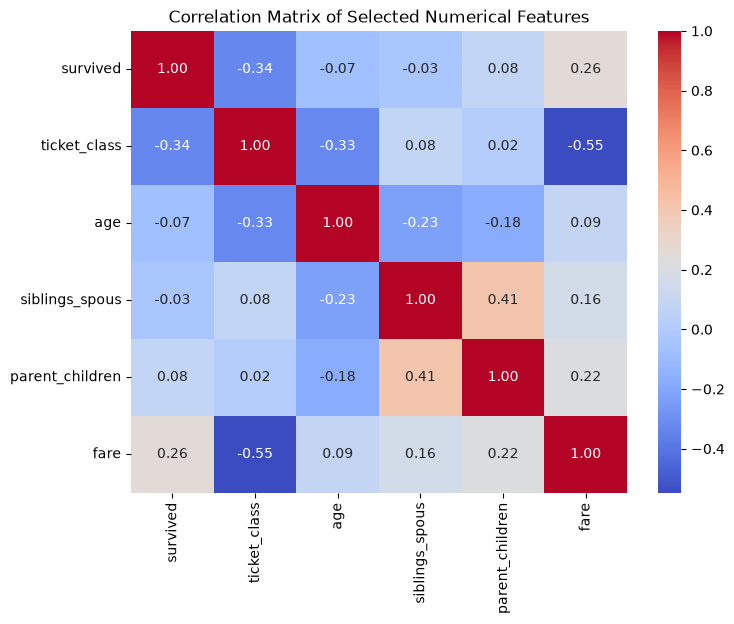

In [ ]:
# Correlation Matrix
print("\n--- Correlation Matrix --- ")
# Use exactly the required six columns for this EDA correlation check
required_corr_cols = ["survived", "ticket_class", "age", "siblings_spous", "parent_children", "fare"]
correlation_matrix = df[required_corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Required Feature Set')
plt.show()

### Strongest correlations interpretation

The two strongest linear relationships among the numerical features are:

1. `ticket_class` and `fare` with a correlation of -0.5495.
   This is the largest absolute off-diagonal correlation in the matrix. The negative sign indicates that higher ticket classes are associated with lower numeric class codes and higher fare values, which reflects the pricing structure of the Titanic cabins: first-class tickets were much more expensive than third-class tickets.

2. `siblings_spous` and `parent_children` with a correlation of 0.4148.
   This is the second strongest association. The positive relationship suggests that passengers traveling with more siblings or spouses also tended to travel with more parents or children, which is consistent with family groups moving together during the journey.

These findings show that the most important relationships are driven by class pricing and family travel patterns rather than random noise in the dataset.

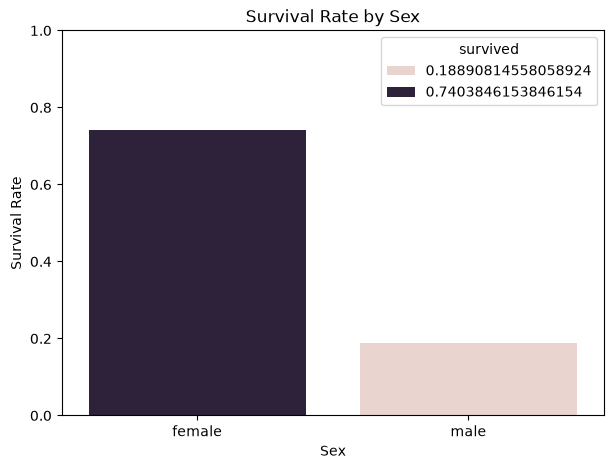

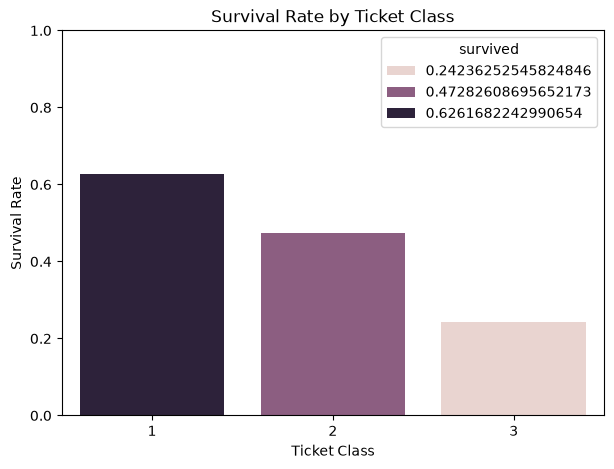

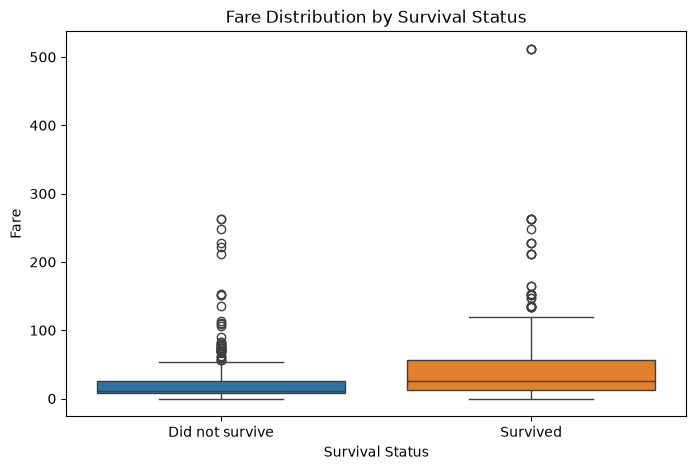

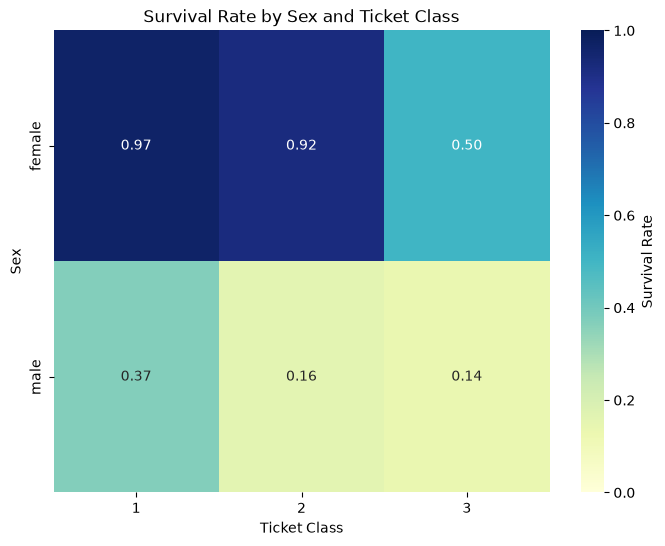

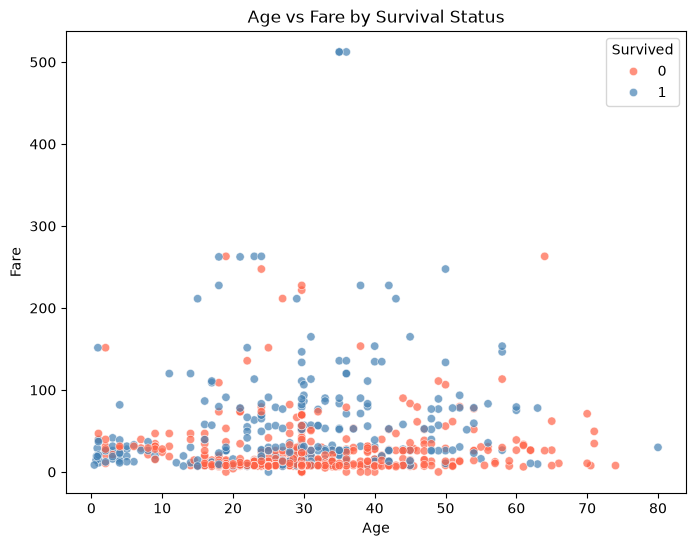

In [79]:
# Coherent survival narrative: sex, class, fare, and their interaction

# Survival rate by sex
survival_by_sex = df.groupby('sex')['survived'].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, hue = survival_by_sex)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()


# Survival rate by ticket class
survival_by_class = df.groupby('ticket_class')['survived'].mean().sort_index()
plt.figure(figsize=(7, 5))
sns.barplot(x=survival_by_class.index.astype(str), y=survival_by_class.values, hue = survival_by_class)
plt.title('Survival Rate by Ticket Class')
plt.xlabel('Ticket Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()


# Fare distribution by survival status
survival_labels = df['survived'].map({0: 'Did not survive', 1: 'Survived'})
plt.figure(figsize=(8, 5))
sns.boxplot(x=survival_labels, y=df['fare'], order=['Did not survive', 'Survived'], hue = survival_labels)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Fare')
plt.show()

# Age Distribution of Survivors vs. Non-Survivors
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', kde=True, palette='coolwarm')
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
print("")

# Heatmap of survival rate by sex and ticket class
survival_by_sex_class = df.groupby(['sex', 'ticket_class'])['survived'].mean().unstack()
plt.figure(figsize=(8, 6))
sns.heatmap(
    survival_by_sex_class,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Survival Rate'}
)
plt.title('Survival Rate by Sex and Ticket Class')
plt.xlabel('Ticket Class')
plt.ylabel('Sex')
plt.show()

# Scatter plot of fare vs age, colored by survival
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    hue='survived',
    palette={0: 'tomato', 1: 'steelblue'},
    alpha=0.7
)
plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived')
plt.show()


### Survival narrative

#### Sex and survival
Women were much more likely to survive than men, with survival rates around 74% versus 19%. This pattern suggests that sex was one of the strongest predictors of survival in the disaster. In the Titanic context, women and children were prioritized during evacuation procedures.

#### Class and survival
Higher ticket classes correspond to dramatically higher survival rates, falling from about 63% in first class to 24% in third class. This indicates that social class and access to better cabins were tightly linked to survival. The gradient is consistent with the idea that passengers in more expensive cabins were closer to lifeboats and more likely to be assisted during evacuation.

#### Fare and socioeconomic advantage
Passengers who survived had substantially higher fare distributions than those who did not, with median fares far above the non-survivor group. This indicates that wealthier passengers were more likely to occupy more favorable positions on the ship and had greater access to safety. Fare therefore serves as a practical proxy for socioeconomic advantage in the crisis.

#### Age distribution and survival
The histogram illustrates the age distribution of passengers, separated by survival status. We can observe a higher proportion of non-survivors in the young adult and middle-aged groups. Conversely, very young children (infants) seem to have a relatively higher survival rate, possibly reflecting 'women and children first' policies, though overall counts for children are lower.

#### Sex and class interaction
The heatmap shows that female survival was high across all classes, but especially among women in first and second class, where survival approached 97% and 92%. Men, by contrast, remained unlikely to survive even in first class, with rates below 37%. This interaction suggests that class and sex worked together: being a woman was protective, and being a woman in a higher class was even more protective.

#### Overall interpretation
The scatter plot shows that survivors were not simply younger or older; rather, they were disproportionately clustered in the higher-fare range. This supports the broader argument that wealth and social position improved survival odds, while age alone was not the primary driver. The combination of class advantage and prioritization policies appears to explain the most important differences in outcomes.

Before scaling summary:
          age     fare
mean  29.6534  32.0967
std   12.9684  49.6975

After z-score scaling summary:
      age_z_eda  fare_z_eda
mean     0.0000      0.0000
std      1.0006      1.0006


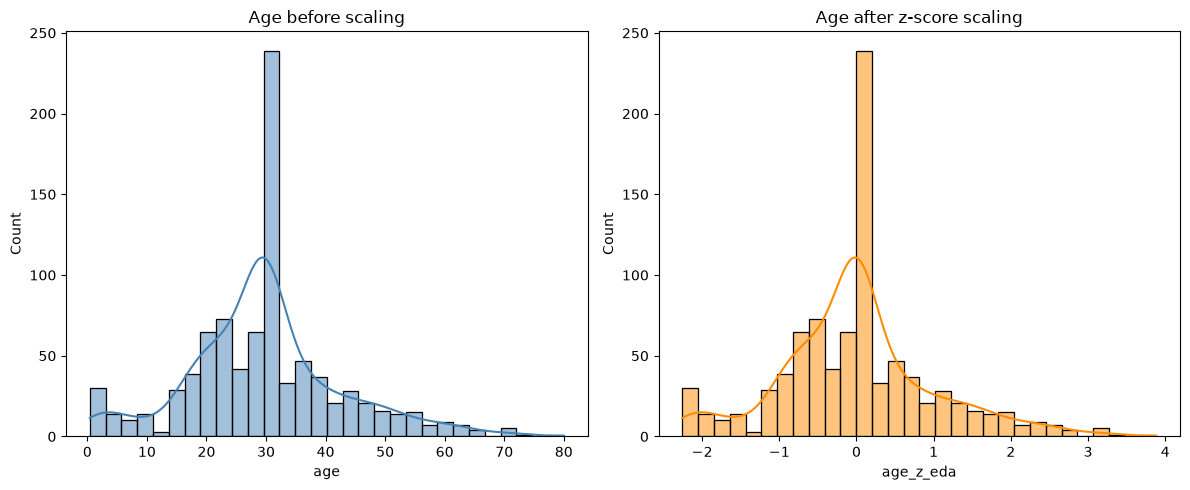

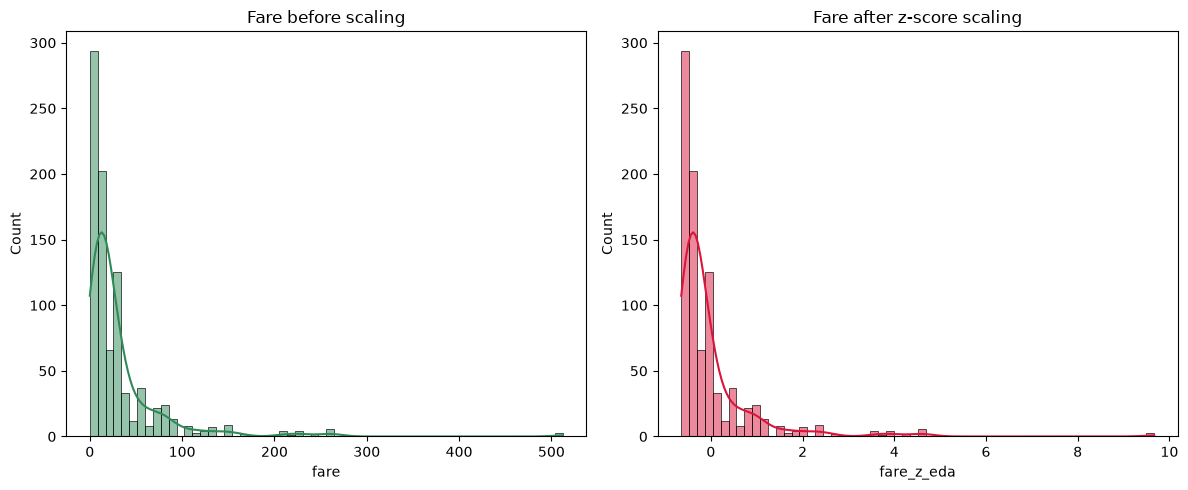


Sanity check: the scaled columns should have mean approximately 0 and std approximately 1.


In [80]:
# EDA-only z-score standardization check for age and fare
# This is not used by the modeling pipeline; it is only a sanity check for exploration.

age_mean = df['age'].mean()
age_std = df['age'].std(ddof=0)
fare_mean = df['fare'].mean()
fare_std = df['fare'].std(ddof=0)

df['age_z_eda'] = (df['age'] - age_mean) / age_std
df['fare_z_eda'] = (df['fare'] - fare_mean) / fare_std

print('Before scaling summary:')
print(df[['age', 'fare']].agg(['mean', 'std']).round(4))
print('\nAfter z-score scaling summary:')
print(df[['age_z_eda', 'fare_z_eda']].agg(['mean', 'std']).round(4))

# Optional visual comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color='steelblue')
plt.title('Age before scaling')
plt.subplot(1, 2, 2)
sns.histplot(df['age_z_eda'], kde=True, color='darkorange')
plt.title('Age after z-score scaling')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['fare'], kde=True, color='seagreen')
plt.title('Fare before scaling')
plt.subplot(1, 2, 2)
sns.histplot(df['fare_z_eda'], kde=True, color='crimson')
plt.title('Fare after z-score scaling')
plt.tight_layout()
plt.show()

print('\nSanity check: the scaled columns should have mean approximately 0 and std approximately 1.')